# 00 — Deep-notched single run

This notebook runs one `deep_notched` training with default config values, with options:

1. `task.type = "forward"/"inverse"`
2. `problem.material.law = "isotropic"/"orthotropic"`

Then it plots the final predicted fields.

In [12]:
from pathlib import Path
import importlib

import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config
import phd.models.cm.deep_notched as dn
from phd.plot import book_config, get_current_config as plt_cfg

# Ensure notebook uses latest local edits in deep_notched.py
dn = importlib.reload(dn)

book_config.set_as_current()
plot_cfg = plt_cfg()
page_width = plot_cfg.page_width if plot_cfg is not None else 7.0

save_fig = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "02_deep_notched"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
PDF_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
def build_cfg(seed: int = 0, material_law: str = "isotropic", with_dic: bool = True, task: str = "forward"):
    cfg = load_config("deep_notched")

    cfg.seed = seed
    cfg.task.type = task
    cfg.problem.material.law = material_law

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 3
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32
    cfg.model.architecture.activations = "tanh"
    # cfg.model.architecture.mlp_type = "modified_mlp"
    cfg.model.fourier_features.enabled = True
    cfg.model.fourier_features.n_features = 128

    cfg.training.n_iter = 10000
    cfg.training.lr = 1e-3
    # cfg.training.lr_decay = ["warmup cosine", 1e-4, 1e-3, 1000, 30000, 1e-4]
    cfg.training.log_every = 250
    cfg.training.num_domain = 300 ** 2
    cfg.training.coord_normalization = True
    cfg.training.self_attention.enabled = True
    cfg.training.self_attention.share_weights = False
    # cfg.training.loss_weights = [1.0]*8 + [1e1]*2
    cfg.training.loss_normalization.scheme = "grad_norm"
    cfg.training.loss_normalization.n_warmup = 100

    cfg.problem.bc.displacement_bc_top = True #not with_dic
    cfg.problem.bc.displacement_bc_bottom = True #not with_dic
    cfg.problem.bc.corner_eps = 0


    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.task.measurements.enabled = with_dic
    cfg.task.measurements.n_observations.x = 100
    cfg.task.measurements.n_observations.y = 100
    cfg.task.measurements.dic.region = [0.05, 0.95, 0.3, 0.7]
    cfg.task.measurements.noise_std = 1e-5

    return cfg

In [16]:
# Run or load
run_mode = "run"  # "run" or "load"

task = "forward" # "forward" or "inverse"
material_law = "isotropic"  # "isotropic" or "orthotropic"
with_dic = False  # Whether to include DIC measurements

run_name = f"{task}_{material_law}{'_with_dic' if with_dic else ''}"

if run_mode == "run":
    cfg = build_cfg(seed=0, material_law=material_law, with_dic=with_dic, task=task)
    results = dn.train(cfg)
    run_dir = dn.save_run_data(results, run_name=run_name, base_dir=cfg.results.base_dir)
elif run_mode == "load":
    results = dn.load_run(run_name, base_dir=PROJECT_ROOT / "results")
    cfg = results["config"]
else:
    raise ValueError("run_mode must be 'run' or 'load'.")

Set the default automatic differentiation to forward mode.
Compiling model...
'compile' took 0.106365 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric   
0         [3.40e-03, 4.59e-03, 3.01e+02, 3.44e+03, 1.23e+02, 1.07e+07, 4.81e-01, 5.14e-01]    [3.43e-03, 4.61e-03, 3.01e+02, 3.45e+03, 1.23e+02, 1.07e+07, 4.81e-01, 5.14e-01]    [1.00e+00]    
100       [2.71e-02, 8.52e-01, 1.64e+02, 2.14e+02, 4.44e+00, 7.29e+03, 7.00e+02, 8.96e+02]    [2.17e-02, 6.82e-01, 1.50e+02, 1.92e+02, 3.66e+00, 7.29e+03, 7.00e+02, 8.96e+02]    [3.31e-01]    

Best model at step 100:
  train loss: 9.27e+03
  test loss: 9.24e+03
  test metric: [3.31e-01]

'train' took 23.315379 s

Applying loss weighting scheme: grad_norm
  base_loss_weights=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  grad_norms=[0.23184983432292938, 3.5166077613830566, 556.147216796875

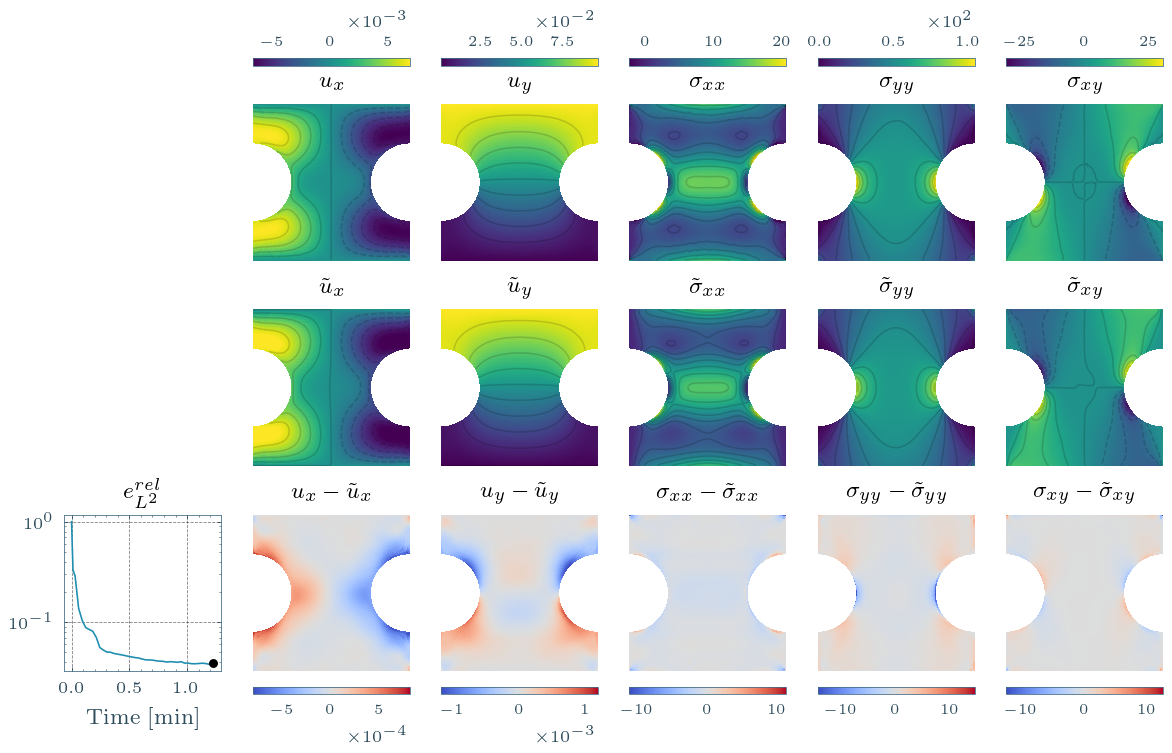

In [17]:
# Plot and save results
fig, artists = dn.plot_results(
    results,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Ux", "Uy", "Sxx", "Syy", "Sxy"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
    side_panel="variables",
    # color_percentile=99.8,
)

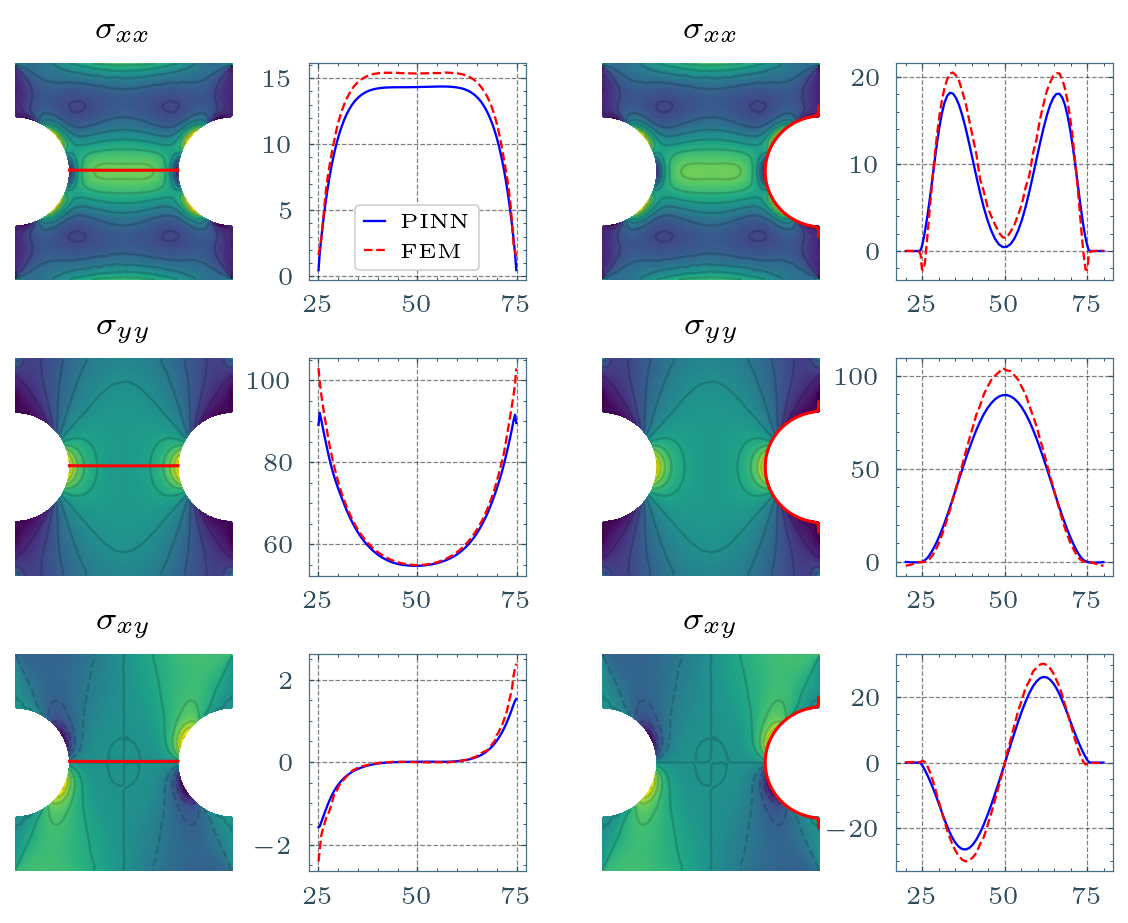

In [19]:
import importlib

import phd.plot.plot_util as plot_util
import phd.plot.plot_cm as plot_cm
import phd.plot as phd_plot
import phd.models.cm.deep_notched as dn

# Reload in dependency order so deep_notched rebinds updated plot functions
plot_util = importlib.reload(plot_util)
plot_cm = importlib.reload(plot_cm)
phd_plot = importlib.reload(phd_plot)
dn = importlib.reload(dn)

# Slice plots (mapped geometry + 1D profiles)
fig, axs = plt.subplots(3,4,figsize=(page_width, page_width * 0.75), dpi=300, gridspec_kw={'wspace': 0.35, 'hspace': 0.3})
fig_slice, ax_slice = dn.plot_slice_results(
    results,
    iteration=-1,
    fields=["Sxx", "Syy", "Sxy"],
    slice_specs=[
        {
            "direction": "horizontal",
            "value": 50.0,
            "min": 0.0,
            "max": 100.0,
            "title": "Horizontal Slice @ y=50",
        },
        {
            "direction": "vertical",
            "value": 100.0,
            "min": 20.0,
            "max": 80.0,
            "title": "Vertical Slice @ x=100",
        },
    ],
    # dic_region=results["config"].task.measurements.dic.region,
    dpi=200,
    fig=fig,
    ax=axs,
    plot_contours=True,
    # color_percentile=99.7,
    
)

if save_fig:
    fig_slice.savefig(IMAGE_DIR / "deep_notched_stress_slices.png", dpi=300, bbox_inches="tight")
    fig_slice.savefig(PDF_DIR / "deep_notched_stress_slices.pdf", bbox_inches="tight")

plt.show()

In [14]:
results["config"].task.measurements.dic.region

[0.05, 0.95, 0.2, 0.8]